In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:\\Users\\sanch\\OneDrive\\Desktop\\flight-delay-intelligence\\data\\cleaned\\featured_flights.csv")

In [5]:
df["Used Date"] = pd.to_datetime(df["Used Date"])

In [7]:
daily_delay = df.groupby("Used Date")["Total Delay"].mean()

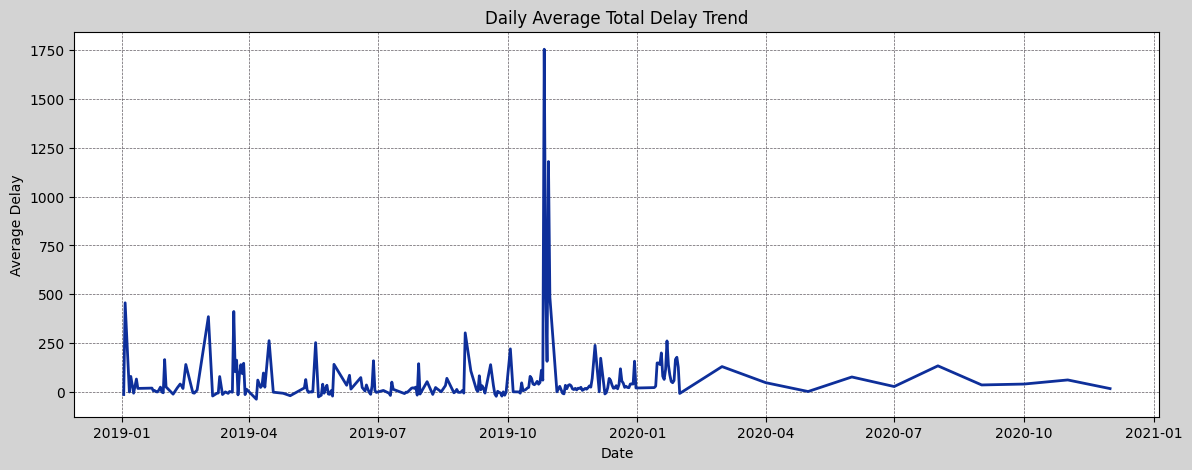

In [9]:
plt.figure(figsize=(14,5), facecolor="lightgray")

plt.plot(
    daily_delay.index,
    daily_delay.values,
    color="#0E2F9A",
    linewidth=2
)

plt.title("Daily Average Total Delay Trend")
plt.xlabel("Date")
plt.ylabel("Average Delay")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.show()

In [10]:
rolling_delay = daily_delay.rolling(window=7).mean()

#### Insights :
The airline delay pattern is highly volatile, with frequent spikes in daily delays.
Most days maintain relatively low average delays, but several extreme peaks occur across the timeline.
A massive delay spike is observed around late 2019, where average delays exceed 1700 minutes, indicating a major operational disruption event.
Delay fluctuations are irregular, suggesting that airline delays are influenced by unpredictable external factors such as:
weather conditions,
airport congestion,
operational inefficiencies,
seasonal travel rush.
Business Interpretation
The aviation system experiences occasional operational breakdowns that drastically increase delays.
Extreme spikes can negatively affect:
customer satisfaction,
airline operational cost,
airport traffic management,
on-time performance metrics.

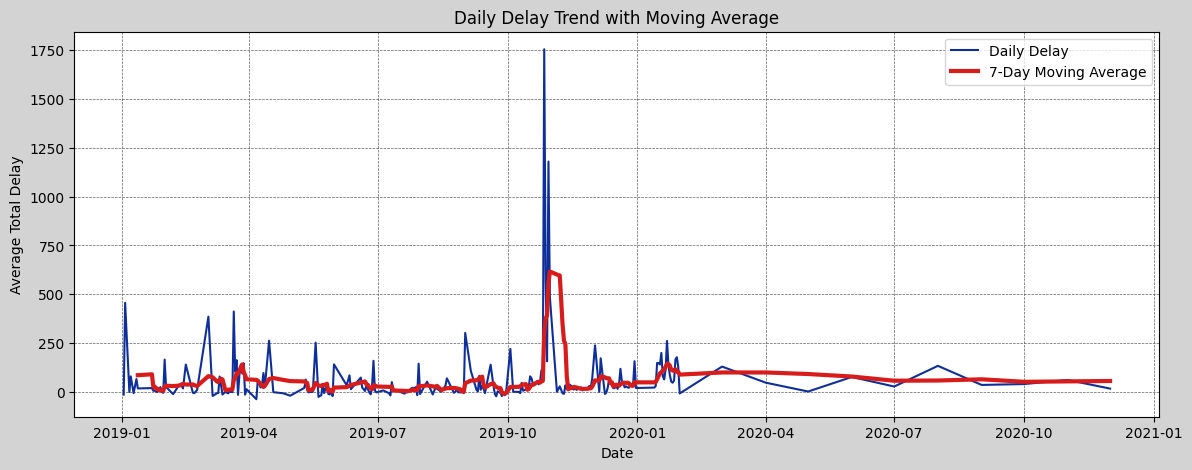

In [16]:
plt.figure(figsize=(14,5), facecolor="lightgray")

# Original daily delays
plt.plot(
    daily_delay.index,
    daily_delay.values,
    color="#0E2F9A",
    label="Daily Delay"
)

# Smoothed trend
plt.plot(
    rolling_delay.index,
    rolling_delay.values,
    color="#D81B1B",
    linewidth=3,
    label="7-Day Moving Average"
)

plt.title("Daily Delay Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Average Total Delay")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.legend()

plt.show()

#### Insights :
The 7-day moving average smooths short-term fluctuations and reveals the overall operational trend.
Despite daily volatility, the moving average remains comparatively stable for most periods.
A sharp rise in the moving average occurs during the extreme delay spike period, confirming that the disruption lasted multiple consecutive days rather than being a single isolated event.
After the spike, the moving average gradually stabilizes, indicating operational recovery.
Business Interpretation
The moving average helps identify sustained congestion periods.
Operational disruptions have lingering effects over several days.
Airlines may require:
improved scheduling,
better crew/resource allocation,
stronger disruption management systems.
Technical Observation
Moving averages successfully reduce noise and make long-term trends easier to analyze for forecasting models.

In [13]:
monthly_delay = df.groupby("Month")["Total Delay"].mean()

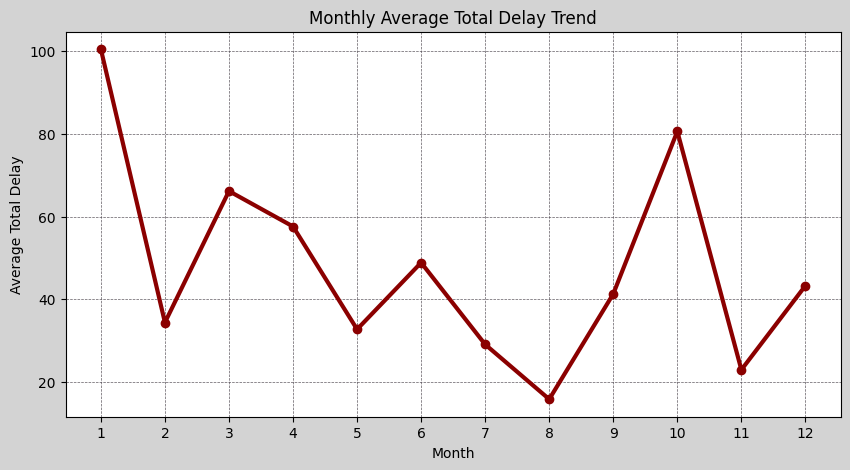

In [15]:
plt.figure(figsize=(10,5), facecolor="lightgray")

plt.plot(
    monthly_delay.index,
    monthly_delay.values,
    marker="o",
    linewidth=3,
    color="darkred"
)

plt.title("Monthly Average Total Delay Trend")
plt.xlabel("Month")
plt.ylabel("Average Total Delay")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.xticks(monthly_delay.index)

plt.show()

#### Insights :
January recorded the highest average delay (~100 minutes).
October showed another major delay increase (~80 minutes).
August experienced the lowest average delays (~15 minutes).
Delays vary significantly across months, indicating strong seasonality effects.
Seasonal Interpretation

Possible causes for high-delay months:

Winter fog conditions
Holiday travel congestion
Festival/vacation traffic
Weather-related operational challenges
Business Insight
Airline operations are seasonally affected.
Airports and airlines should increase operational preparedness during:
January,
October,
peak travel months.
Operational Recommendation

During high-delay seasons:

increase staffing,
optimize gate management,
improve flight scheduling,
enhance weather monitoring systems.

In [17]:
from statsmodels.tsa.arima.model import ARIMA

In [18]:
model = ARIMA(monthly_delay, order=(1,1,1))
model_fit = model.fit()

c:\Users\sanch\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\sanch\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\sanch\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


#### Forecast Next 3 Months

In [19]:
forecast = model_fit.forecast(steps=3)

print(forecast)

12    41.715701
13    42.166674
14    42.037484
Name: predicted_mean, dtype: float64


c:\Users\sanch\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\sanch\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


#### Plot Forecast

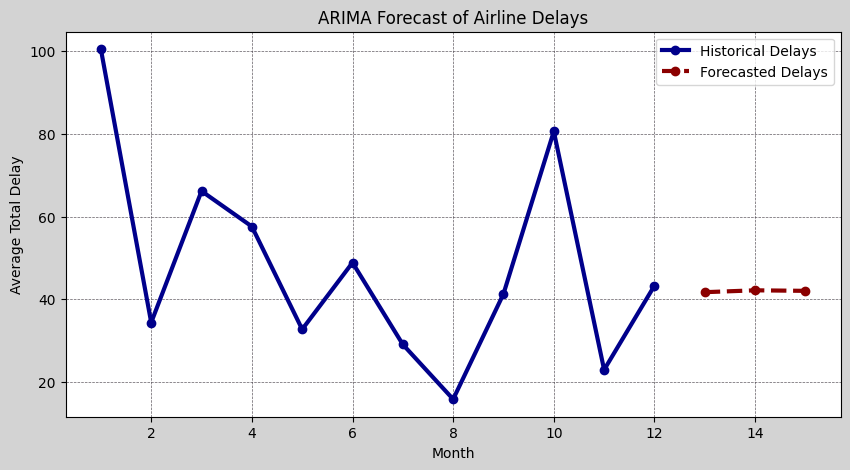

In [20]:
plt.figure(figsize=(10,5), facecolor="lightgray")

# Original monthly delays
plt.plot(
    monthly_delay.index,
    monthly_delay.values,
    marker="o",
    linewidth=3,
    color="darkblue",
    label="Historical Delays"
)

# Forecast
future_months = [13,14,15]

plt.plot(
    future_months,
    forecast,
    marker="o",
    linestyle="--",
    linewidth=3,
    color="darkred",
    label="Forecasted Delays"
)

plt.title("ARIMA Forecast of Airline Delays")
plt.xlabel("Month")
plt.ylabel("Average Total Delay")

plt.grid(
    True,
    linestyle="--",
    color="#504951",
    alpha=0.9,
    linewidth=0.5
)

plt.legend()

plt.show()

#### Insights :
The ARIMA model predicts relatively stable future delays around 42 minutes.
Forecast values show minimal fluctuation, indicating stabilization in future operational performance.
Historical data contains strong fluctuations, but the forecast smooths future expectations.
Forecast Interpretation
The model suggests that:
future delays may remain moderate,
no major upward delay trend is currently expected,
operations may become more predictable over time.
Technical Insight
ARIMA effectively captures:
trend patterns,
temporal dependencies,
historical delay behavior.
Limitation Observation
Since historical data contains extreme spikes, forecast accuracy may improve further with:
SARIMA,
Prophet,
exogenous weather variables,
holiday/event indicators.